# Data Exploration & Preprocessing
**Credit Card Fraud Detection Project**  
INFO 5368: Practical Applications in Machine Learning

This notebook covers:
1. Data loading and validation
2. Exploratory data analysis (EDA)
3. Preprocessing pipeline
4. Train/test split verification

## 1. Data Loading & Validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

# Add parent dir so we can import our modules
sys.path.insert(0, os.path.abspath('..'))

# Load the raw dataset
df = pd.read_csv('../data/creditcard.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Basic stats
print(f"Total transactions: {len(df):,}")
print(f"Fraud (Class=1):   {df['Class'].sum():,}  ({df['Class'].mean()*100:.4f}%)")
print(f"Legit (Class=0):   {(df['Class']==0).sum():,}")
print(f"\nMissing values:    {df.isnull().sum().sum()}")
print(f"All numeric:       {all(df.dtypes != object)}")
print(f"\nFeature types:")
print(f"  PCA features (V1-V28): 28 columns")
print(f"  Time: seconds since first transaction")
print(f"  Amount: transaction amount in EUR")
print(f"  Class: 0=legit, 1=fraud")

Total transactions: 284,807
Fraud (Class=1):   492  (0.1727%)
Legit (Class=0):   284,315

Missing values:    0
All numeric:       True

Feature types:
  PCA features (V1-V28): 28 columns
  Time: seconds since first transaction
  Amount: transaction amount in EUR
  Class: 0=legit, 1=fraud


## 2. Exploratory Data Analysis

### 2.1 Class Distribution

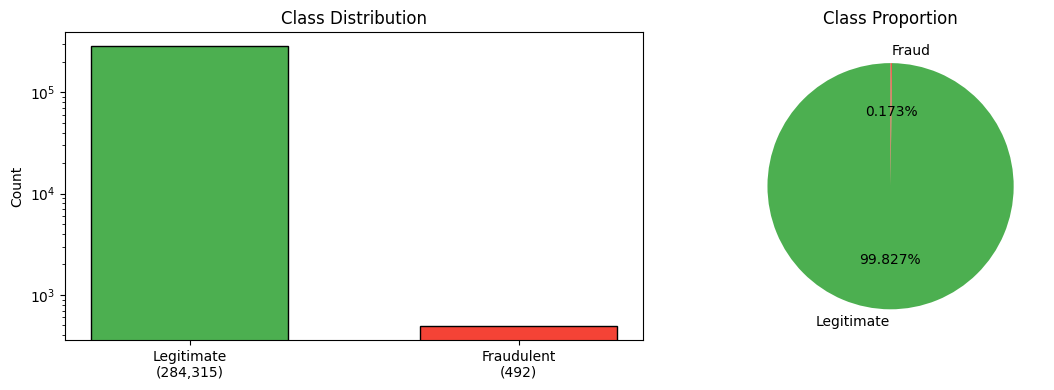

Class imbalance ratio: 578:1 (legit:fraud)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['Class'].value_counts().sort_index()
axes[0].bar(['Legitimate\n(284,315)', 'Fraudulent\n(492)'], counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black', width=0.6)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
axes[0].set_yscale('log')

# Pie chart
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'], autopct='%1.3f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {counts[0]/counts[1]:.0f}:1 (legit:fraud)")

### 2.2 Transaction Amount Distribution

/var/folders/_7/y0_zbpt55x5cz8flmzkt89rm0000gn/T/ipykernel_8460/467067407.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([legit['Amount'], fraud['Amount']], labels=['Legitimate', 'Fraud'],


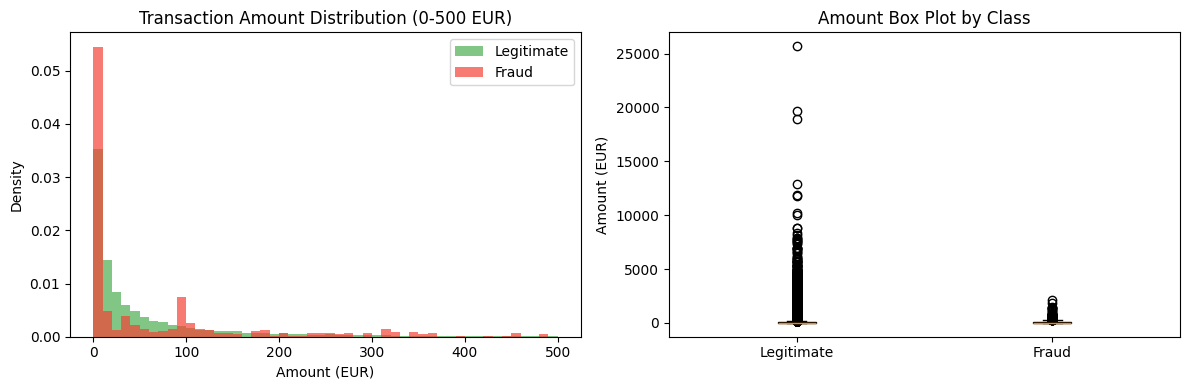

Amount statistics:
  Legit: mean=88.29, median=22.00, max=25691.16
  Fraud: mean=122.21, median=9.25, max=2125.87


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# Amount histogram by class
axes[0].hist(legit['Amount'], bins=50, alpha=0.7, color='#4CAF50', label='Legitimate',
             density=True, range=(0, 500))
axes[0].hist(fraud['Amount'], bins=50, alpha=0.7, color='#F44336', label='Fraud',
             density=True, range=(0, 500))
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Amount Distribution (0-500 EUR)')
axes[0].legend()

# Amount statistics
axes[1].boxplot([legit['Amount'], fraud['Amount']], labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E0E0E0'))
axes[1].set_ylabel('Amount (EUR)')
axes[1].set_title('Amount Box Plot by Class')

plt.tight_layout()
plt.show()

print("Amount statistics:")
print(f"  Legit: mean={legit['Amount'].mean():.2f}, median={legit['Amount'].median():.2f}, max={legit['Amount'].max():.2f}")
print(f"  Fraud: mean={fraud['Amount'].mean():.2f}, median={fraud['Amount'].median():.2f}, max={fraud['Amount'].max():.2f}")

### 2.3 Transaction Volume Over Time

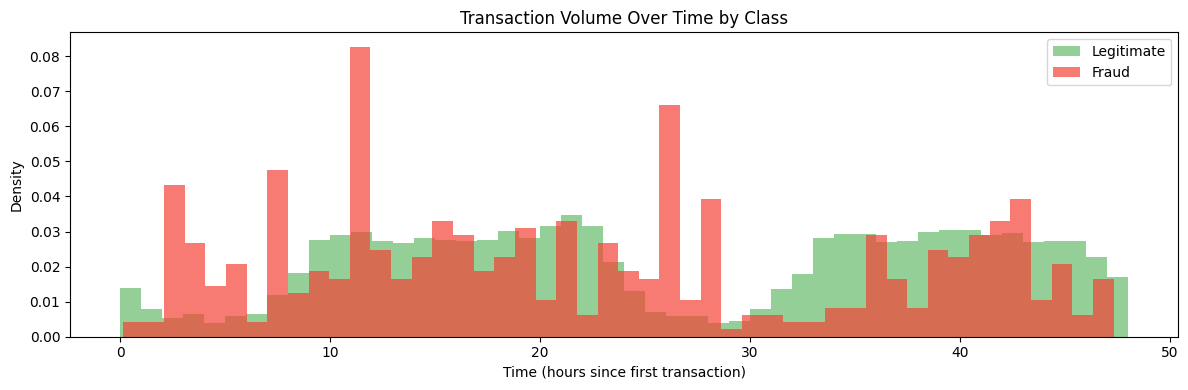

Dataset spans 48.0 hours (2.0 days)


In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

# Bin time into hourly intervals
df['Hour'] = df['Time'] / 3600

legit_hours = df.loc[df['Class']==0, 'Hour']
fraud_hours = df.loc[df['Class']==1, 'Hour']

ax.hist(legit_hours, bins=48, alpha=0.6, color='#4CAF50', label='Legitimate', density=True)
ax.hist(fraud_hours, bins=48, alpha=0.7, color='#F44336', label='Fraud', density=True)
ax.set_xlabel('Time (hours since first transaction)')
ax.set_ylabel('Density')
ax.set_title('Transaction Volume Over Time by Class')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Dataset spans {df['Time'].max()/3600:.1f} hours ({df['Time'].max()/3600/24:.1f} days)")

### 2.4 PCA Feature Distributions (Fraud vs Legitimate)

Top 6 most discriminative PCA features: ['V3', 'V14', 'V17', 'V12', 'V10', 'V7']


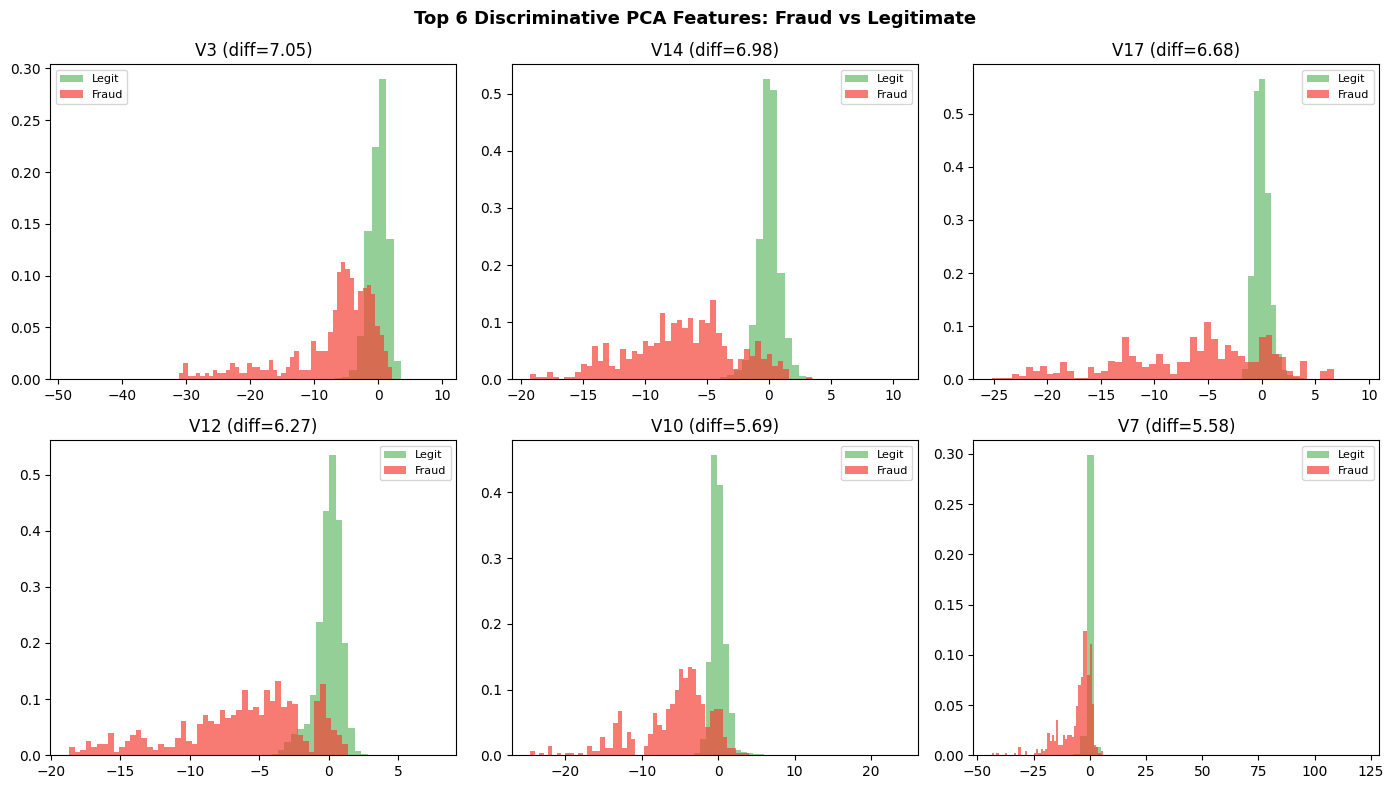

In [6]:
# Select the most discriminative features based on mean difference
features = [f'V{i}' for i in range(1, 29)]
mean_diff = {}
for f in features:
    diff = abs(fraud[f].mean() - legit[f].mean())
    mean_diff[f] = diff

# Top 6 most discriminative features
top_features = sorted(mean_diff, key=mean_diff.get, reverse=True)[:6]
print(f"Top 6 most discriminative PCA features: {top_features}")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].hist(legit[feat], bins=50, alpha=0.6, color='#4CAF50', label='Legit', density=True)
    axes[i].hist(fraud[feat], bins=50, alpha=0.7, color='#F44336', label='Fraud', density=True)
    axes[i].set_title(f'{feat} (diff={mean_diff[feat]:.2f})')
    axes[i].legend(fontsize=8)

plt.suptitle('Top 6 Discriminative PCA Features: Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Feature Correlation Heatmap

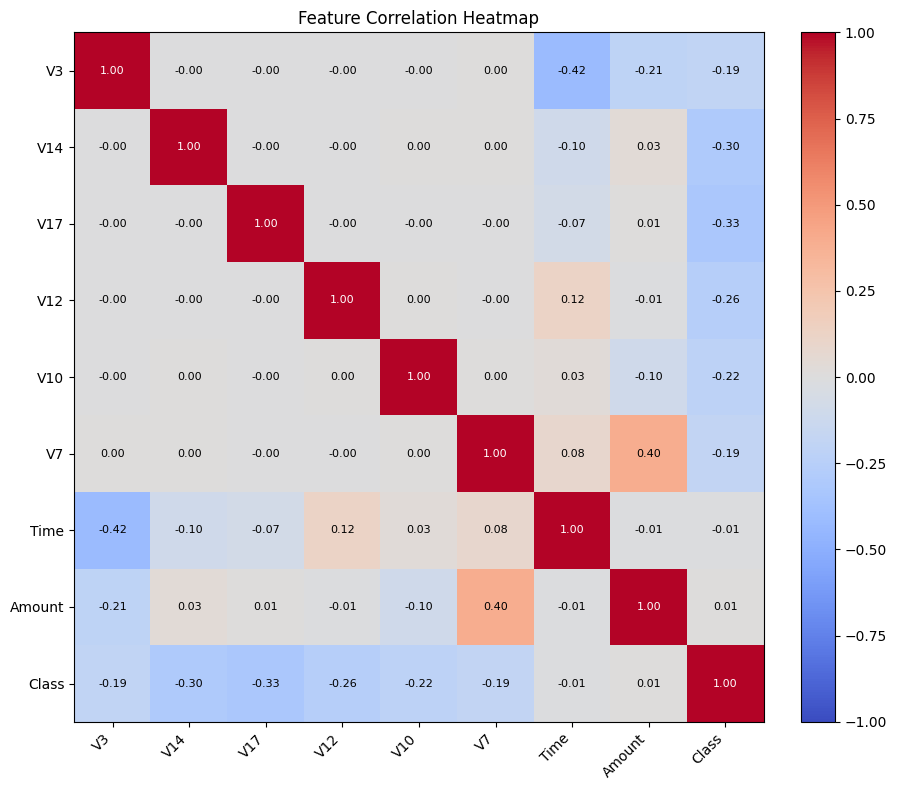


Correlation with Class (fraud):
  Most negative (higher = more legit):
    V17: -0.3265
    V14: -0.3025
    V12: -0.2606
    V10: -0.2169
    V16: -0.1965
  Most positive (higher = more fraud):
    V19: 0.0348
    V21: 0.0404
    V2: 0.0913
    V4: 0.1334
    V11: 0.1549


In [7]:
# Correlation of top features + Time + Amount + Class
selected = top_features + ['Time', 'Amount', 'Class']
corr = df[selected].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(selected)))
ax.set_yticks(range(len(selected)))
ax.set_xticklabels(selected, rotation=45, ha='right')
ax.set_yticklabels(selected)

# Add correlation values
for i in range(len(selected)):
    for j in range(len(selected)):
        color = 'white' if abs(corr.iloc[i, j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color=color)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Check which features correlate with Class
print("\nCorrelation with Class (fraud):")
class_corr = df[features + ['Time', 'Amount']].corrwith(df['Class']).sort_values()
print("  Most negative (higher = more legit):")
for feat, val in class_corr.head(5).items():
    print(f"    {feat}: {val:.4f}")
print("  Most positive (higher = more fraud):")
for feat, val in class_corr.tail(5).items():
    print(f"    {feat}: {val:.4f}")

### 2.6 Scatter Plots of Top Features

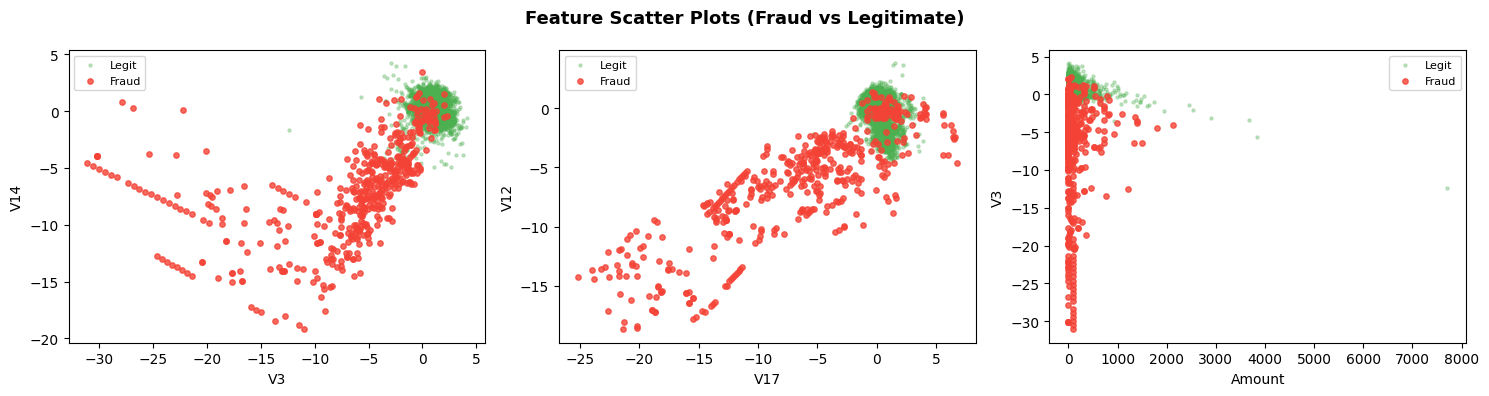

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [(top_features[0], top_features[1]),
         (top_features[2], top_features[3]),
         ('Amount', top_features[0])]

for i, (f1, f2) in enumerate(pairs):
    # Plot legit first (background), fraud on top
    axes[i].scatter(legit[f1].values[:5000], legit[f2].values[:5000],
                    alpha=0.3, s=5, c='#4CAF50', label='Legit')
    axes[i].scatter(fraud[f1], fraud[f2],
                    alpha=0.8, s=15, c='#F44336', label='Fraud')
    axes[i].set_xlabel(f1)
    axes[i].set_ylabel(f2)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Scatter Plots (Fraud vs Legitimate)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing Pipeline

Our preprocessing steps (implemented in `preprocessing.py`):
1. **Missing value check** - dataset has none
2. **Stratified train/test split** (80/20) - preserves fraud ratio
3. **IQR outlier capping** on Amount - prevents extreme values from dominating
4. **Z-score normalization** on Time and Amount - matches PCA feature scale
5. **Random undersampling** of majority class in training set - balances classes for training

In [9]:
from preprocessing import build_pipeline

X_train, y_train, X_test, y_test, raw_df, scaler_params = build_pipeline(
    filepath='../data/creditcard.csv',
    test_size=0.2,
    undersample_ratio=5.0,
    cap_amount_outliers=True,
    random_state=42,
    save_dir='../saved_models'
)


>>> Step 1: Loading data


  Dataset Validation Summary
  Total samples   : 284,807
  Fraud  (Class=1): 492  (0.1727%)
  Legit  (Class=0): 284,315
  Features        : 30  (30 features + 1 label)
  Missing values  : 0
  Dtypes          : all numeric = True



>>> Step 2: Stratified train/test split



  Train set: 227,846 samples  | fraud=394  legit=227452
  Test  set: 56,961  samples  | fraud=98  legit=56863

>>> Step 3: IQR outlier capping on Amount

  IQR outlier capping on 'Amount':
    Q1=5.65  Q3=77.15  IQR=71.50
    Capping range: [-101.60, 184.40]

>>> Step 4: Fit & apply Z-score normalization

  Scaler fitted on training set:
    Time      mean=94863.7082  std=47500.7635
    Amount    mean=51.7208  std=61.6562



>>> Step 5: Saving scaler params

  Scaler params saved to ../saved_models/

>>> Step 6: Undersampling training set

  After undersampling (ratio=5.0):
    Fraud : 394
    Legit : 1970
    Total : 2364

>>> Step 7: Converting to NumPy arrays

  X_train shape: (2364, 30)  y_train: [1970  394]
  X_test  shape: (56961, 30)   y_test:  [56863    98]

>>> Pipeline complete.



In [10]:
# Verify the split
print(f"Training set: {X_train.shape[0]} samples")
print(f"  Fraud: {np.sum(y_train==1)} ({np.sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"  Legit: {np.sum(y_train==0)} ({np.sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Ratio: {np.sum(y_train==0)/np.sum(y_train==1):.1f}:1")
print(f"\nTest set: {X_test.shape[0]} samples (original distribution)")
print(f"  Fraud: {np.sum(y_test==1)} ({np.sum(y_test==1)/len(y_test)*100:.3f}%)")
print(f"  Legit: {np.sum(y_test==0)}")

# Verify normalization
print(f"\nAfter normalization:")
print(f"  Time  - mean: {X_train[:, 28].mean():.4f}, std: {X_train[:, 28].std():.4f}")
print(f"  Amount- mean: {X_train[:, 29].mean():.4f}, std: {X_train[:, 29].std():.4f}")

Training set: 2364 samples
  Fraud: 394 (16.7%)
  Legit: 1970 (83.3%)
  Ratio: 5.0:1

Test set: 56961 samples (original distribution)
  Fraud: 98 (0.172%)
  Legit: 56863

After normalization:
  Time  - mean: -0.0662, std: 1.0067
  Amount- mean: 0.0138, std: 1.0315


## Summary

Key findings from EDA:
- **Extreme class imbalance**: only 0.17% of transactions are fraud (578:1 ratio)
- **Amount patterns**: fraud transactions tend to have different amount distributions than legitimate ones
- **PCA features are discriminative**: several V-features (especially V14, V17, V12, V10) show clear separation between fraud and legitimate classes
- **Low feature correlation**: PCA features are mostly uncorrelated (by design), which is good for our models
- **Preprocessing is critical**: normalization and undersampling are necessary to handle the scale mismatch and class imbalance